   id  noise  comfort_score recommendation
0   1   32.7           95.2         Nyaman
1   2   33.0           96.3         Nyaman
2   3   35.3           93.4         Nyaman
3   4   37.8           87.1         Nyaman
4   5   36.3           88.5         Nyaman

Fuzzy output saved as noise_comfort_fuzzy_result.csv


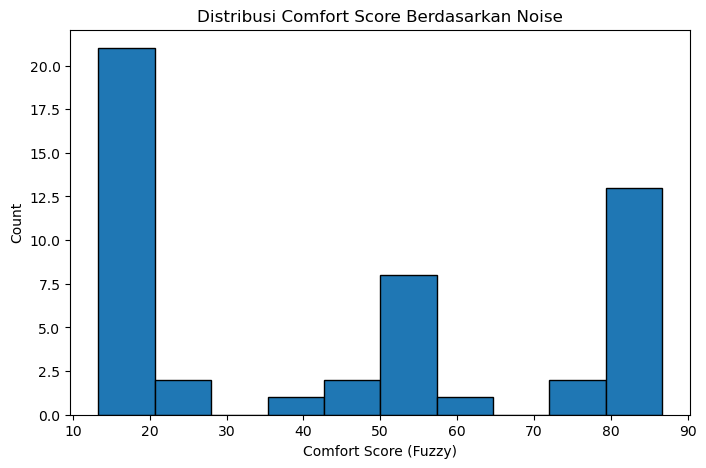

F:\Downloads\anaconda\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


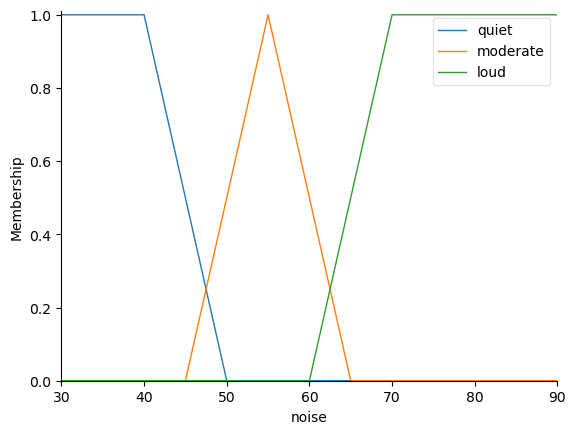

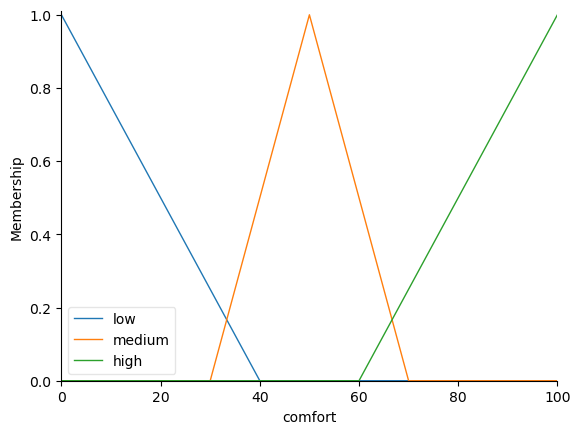

In [1]:
# === Fuzzy Logic: Comfort Level Berdasarkan Noise ===

import numpy as np
import pandas as pd
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('./noise_comfort_dataset.csv')
print(df.head())

# Define fuzzy variables
noise = ctrl.Antecedent(np.arange(30, 91, 1), 'noise')
comfort = ctrl.Consequent(np.arange(0, 101, 1), 'comfort')

# Membership functions
noise['quiet'] = fuzz.trapmf(noise.universe, [30, 30, 40, 50])
noise['moderate'] = fuzz.trimf(noise.universe, [45, 55, 65])
noise['loud'] = fuzz.trapmf(noise.universe, [60, 70, 90, 90])

comfort['low'] = fuzz.trimf(comfort.universe, [0, 0, 40])
comfort['medium'] = fuzz.trimf(comfort.universe, [30, 50, 70])
comfort['high'] = fuzz.trimf(comfort.universe, [60, 100, 100])

# Rules
rule1 = ctrl.Rule(noise['quiet'], comfort['high'])
rule2 = ctrl.Rule(noise['moderate'], comfort['medium'])
rule3 = ctrl.Rule(noise['loud'], comfort['low'])

comfort_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
comfort_sim = ctrl.ControlSystemSimulation(comfort_ctrl) #Simulasi untuk input

#. Function to compute fuzzy output
def compute_comfort(n):
    comfort_sim.input['noise'] = n
    comfort_sim.compute()
    return comfort_sim.output['comfort']

# Apply fuzzy model to dataset (menyeluruh)
df['comfort_fuzzy'] = df['noise'].apply(compute_comfort)

# aturan untuk rekomendasinya
def recommend(score):
    if score >= 70:
        return 'Nyaman'
    elif score >= 40:
        return 'Cukup Nyaman'
    else:
        return 'Tidak Nyaman'

df['recommendation_fuzzy'] = df['comfort_fuzzy'].apply(recommend)

# Save dataset
df.to_csv('noise_comfort_fuzzy_result.csv', index=False)
print("\nFuzzy output saved as noise_comfort_fuzzy_result.csv")

# Plot distributions
plt.figure(figsize=(8,5))
plt.hist(df['comfort_fuzzy'], bins=10, edgecolor='black')
plt.title('Distribusi Comfort Score Berdasarkan Noise')
plt.xlabel('Comfort Score (Fuzzy)')
plt.ylabel('Count')
plt.show()

# Plot membership function
noise.view()
comfort.view()
